In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [16]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train = pd.read_csv('../data/KDDTrain+.txt', names=columns).drop(columns=['difficulty'])
test  = pd.read_csv('../data/KDDTest+.txt',  names=columns).drop(columns=['difficulty'])

dos   = ['back','land','neptune','pod','smurf','teardrop']
probe = ['ipsweep','nmap','portsweep','satan']
r2l   = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster']
u2r   = ['buffer_overflow','loadmodule','perl','rootkit']

def map_label(label):
    if label == 'normal': return 'normal'
    if label in dos:      return 'DoS'
    if label in probe:    return 'Probe'
    if label in r2l:      return 'R2L'
    if label in u2r:      return 'U2R'
    return 'other'

train['label'] = train['label'].apply(map_label)
test['label']  = test['label'].apply(map_label)

# Remove 'other' — unseen attack types handled by autoencoder
train = train[train['label'] != 'other']
test  = test[test['label']  != 'other']

print("Train label distribution:")
print(train['label'].value_counts())
print("\nTest label distribution:")
print(test['label'].value_counts())

Train label distribution:
label
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Test label distribution:
label
normal    9711
DoS       5741
R2L       2199
Probe     1106
U2R         37
Name: count, dtype: int64


In [17]:
cat_cols = ['protocol_type', 'service', 'flag']
le_feat = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([train[col], test[col]])
    le_feat.fit(combined)
    train[col] = le_feat.transform(train[col])
    test[col]  = le_feat.transform(test[col])

le_label = LabelEncoder()
le_label.fit(pd.concat([train['label'], test['label']]))
train['label'] = le_label.transform(train['label'])
test['label']  = le_label.transform(test['label'])

print("Classes:", list(le_label.classes_))

X_train = train.drop(columns=['label'])
y_train = train['label']
X_test  = test.drop(columns=['label'])
y_test  = test['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_res).value_counts().rename(index=dict(enumerate(le_label.classes_))))
print("\nTest set shape:", X_test_scaled.shape)

Classes: ['DoS', 'Probe', 'R2L', 'U2R', 'normal']

After SMOTE:
label
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64

Test set shape: (18794, 41)


In [18]:
print("Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_res, y_res)

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_res, y_res)

print("Training XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    use_label_encoder=False, eval_metric='mlogloss',
                    n_jobs=-1)
xgb.fit(X_res, y_res)

print("\nAll models trained.")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...

All models trained.


In [19]:
class_names = le_label.classes_

for name, model in [("Logistic Regression", lr), ("Random Forest", rf), ("XGBoost", xgb)]:
    preds = model.predict(X_test_scaled)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print('='*45)
    print(classification_report(y_test, preds, target_names=class_names))


  Logistic Regression
              precision    recall  f1-score   support

         DoS       0.99      0.98      0.98      5741
       Probe       0.69      1.00      0.81      1106
         R2L       0.88      0.30      0.45      2199
         U2R       0.05      0.51      0.09        37
      normal       0.88      0.95      0.91      9711

    accuracy                           0.88     18794
   macro avg       0.70      0.75      0.65     18794
weighted avg       0.90      0.88      0.87     18794


  Random Forest
              precision    recall  f1-score   support

         DoS       0.99      0.99      0.99      5741
       Probe       0.82      1.00      0.90      1106
         R2L       0.97      0.03      0.06      2199
         U2R       0.38      0.08      0.13        37
      normal       0.81      0.97      0.88      9711

    accuracy                           0.87     18794
   macro avg       0.79      0.61      0.59     18794
weighted avg       0.88      0.87    

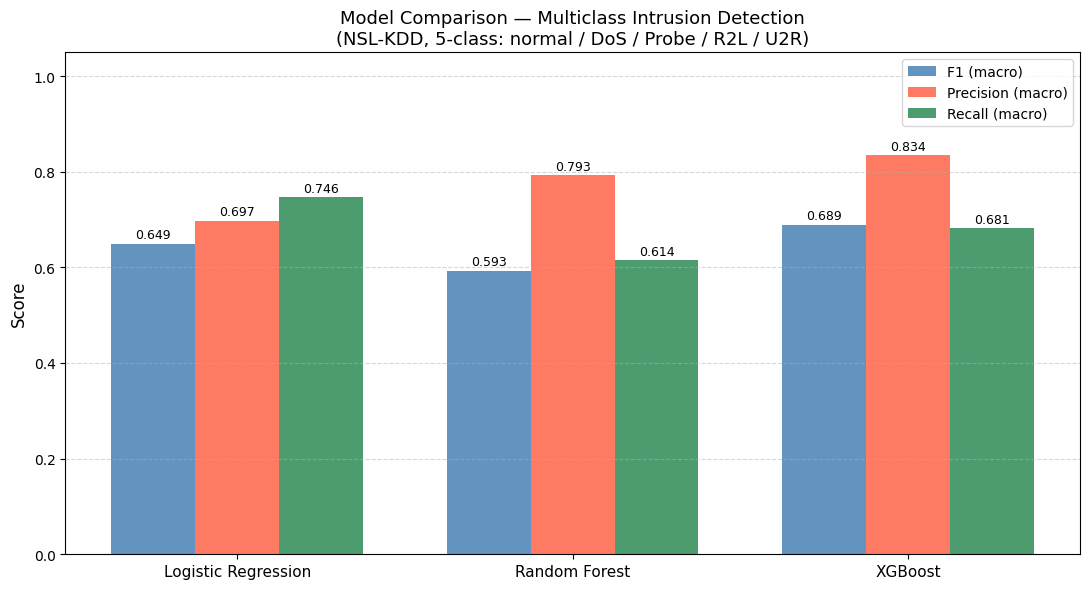

Dashboard saved to model_comparison.png


In [20]:
models     = {"Logistic Regression": lr, "Random Forest": rf, "XGBoost": xgb}
metrics    = {"F1 (macro)": [], "Precision (macro)": [], "Recall (macro)": []}
model_names = list(models.keys())

for model in models.values():
    preds = model.predict(X_test_scaled)
    metrics["F1 (macro)"].append(f1_score(y_test, preds, average='macro'))
    metrics["Precision (macro)"].append(precision_score(y_test, preds, average='macro'))
    metrics["Recall (macro)"].append(recall_score(y_test, preds, average='macro'))

x     = np.arange(len(model_names))
width = 0.25
colors = ['steelblue', 'tomato', 'seagreen']

fig, ax = plt.subplots(figsize=(11, 6))

for i, (metric, values) in enumerate(metrics.items()):
    bars = ax.bar(x + i * width, values, width, label=metric, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Multiclass Intrusion Detection\n(NSL-KDD, 5-class: normal / DoS / Probe / R2L / U2R)',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../model_comparison.png', dpi=150)
plt.show()

print("Dashboard saved to model_comparison.png")